# RNN

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, SimpleRNN, Bidirectional, Dense
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

### Create synthetic time series data

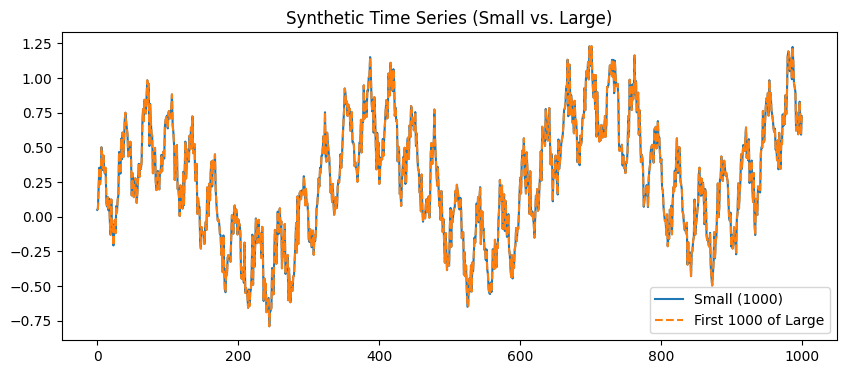

In [14]:
def generate_time_series(length=1000, seed=42):
    np.random.seed(seed)
    t = np.arange(length)
    # create repeating patterns
    signal = (
        0.5 * np.sin(0.02 * t) +          # slow wave
        0.3 * np.sin(0.2 * t) +           # fast oscillation
        0.1 * np.random.randn(length) +   # noise
        0.0005 * t                        # slight upward trend
    )
    return signal

# small and large datasets
series_small = generate_time_series(1000)
series_large = generate_time_series(3000)

plt.figure(figsize=(10,4))
plt.plot(series_small, label="Small (1000)")
plt.plot(series_large[:1000], '--', label="First 1000 of Large")
plt.title("Synthetic Time Series (Small vs. Large)")
plt.legend()
plt.show()

### Prepare sequences for training

In [15]:
def make_sequences(series, window=20):
    X, y = [], []
    for i in range(len(series) - window):
        X.append(series[i:i+window])
        y.append(series[i+1:i+window+1])
    X = np.array(X)[..., np.newaxis]  # (samples, timesteps, features)
    y = np.array(y)[..., np.newaxis]
    return X, y

X_small, y_small = make_sequences(series_small, window=20)
X_large, y_large = make_sequences(series_large, window=20)

print(f"Small dataset shape: X={X_small.shape}, y={y_small.shape}")
print(f"Large dataset shape: X={X_large.shape}, y={y_large.shape}")

Small dataset shape: X=(980, 20, 1), y=(980, 20, 1)
Large dataset shape: X=(2980, 20, 1), y=(2980, 20, 1)


### Define RNN models

In [16]:
def build_model(rnn_type='LSTM', bidirectional=False, deep=False):
    model = Sequential()
    if bidirectional:
        rnn_layer = Bidirectional(eval(rnn_type)(64, return_sequences=deep, input_shape=(X_small.shape[1], 1)))
    else:
        rnn_layer = eval(rnn_type)(64, return_sequences=deep, input_shape=(X_small.shape[1], 1))
    model.add(rnn_layer)

    if deep:
        model.add(eval(rnn_type)(64))

    model.add(Dense(20))  # predict next 20 values
    model.compile(optimizer=Adam(0.001), loss='mse')
    return model

### Train and evaluate

In [18]:
def evaluate_model(model, X, y):
    preds = model.predict(X, verbose=0)

    # Ensure both have same shape
    if preds.ndim == 2:  # (batch, timesteps)
        preds = np.expand_dims(preds, -1)
    if y.ndim == 2:  # (batch, timesteps)
        y = np.expand_dims(y, -1)

    mse = np.mean(np.square(y - preds))
    mae = mean_absolute_error(y.flatten(), preds.flatten())
    r2 = r2_score(y.flatten(), preds.flatten())
    return mse, mae, r2

models_to_test = {
    "LSTM": build_model("LSTM"),
    "GRU": build_model("GRU"),
    "DeepRNN": build_model("SimpleRNN", deep=True),
    "BiRNN": build_model("SimpleRNN", bidirectional=True)
}

results = {}

for name, model in models_to_test.items():
    print(f"\n=== Training {name} on SMALL dataset ===")
    model.fit(X_small, y_small, epochs=10, batch_size=32, verbose=0)
    mse_small, mae_small, r2_small = evaluate_model(model, X_small, y_small)

    print(f"=== Training {name} on LARGE dataset ===")
    model.fit(X_large, y_large, epochs=10, batch_size=32, verbose=0)
    mse_large, mae_large, r2_large = evaluate_model(model, X_large, y_large)

    results[name] = {
        "Small_MSE": mse_small,
        "Small_MAE": mae_small,
        "Small_R2": r2_small,
        "Large_MSE": mse_large,
        "Large_MAE": mae_large,
        "Large_R2": r2_large
    }

results_df = pd.DataFrame(results).T
print("\n=== RNN Performance Comparison ===")
display(results_df)



=== Training LSTM on SMALL dataset ===
=== Training LSTM on LARGE dataset ===

=== Training GRU on SMALL dataset ===
=== Training GRU on LARGE dataset ===

=== Training DeepRNN on SMALL dataset ===
=== Training DeepRNN on LARGE dataset ===

=== Training BiRNN on SMALL dataset ===
=== Training BiRNN on LARGE dataset ===

=== RNN Performance Comparison ===


,Small_MSE,Small_MAE,Small_R2,Large_MSE,Large_MAE,Large_R2
LSTM,0.008959,0.075148,0.949305,0.009053,0.075432,0.975141
GRU,0.009034,0.075442,0.948882,0.008541,0.073072,0.976549
DeepRNN,0.003457,0.044098,0.980438,0.001772,0.028352,0.995136
BiRNN,0.001918,0.030805,0.989146,0.001231,0.021561,0.996621


### Visualize predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


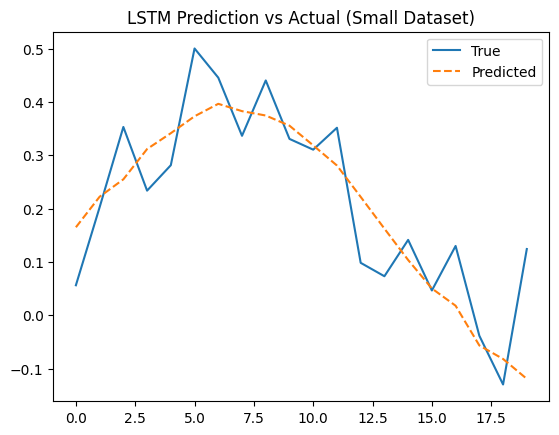

In [21]:
model = models_to_test["LSTM"]
preds = model.predict(X_small[:1])
plt.plot(y_small[0].flatten(), label="True")
plt.plot(preds.flatten(), label="Predicted", linestyle='--')
plt.title("LSTM Prediction vs Actual (Small Dataset)")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


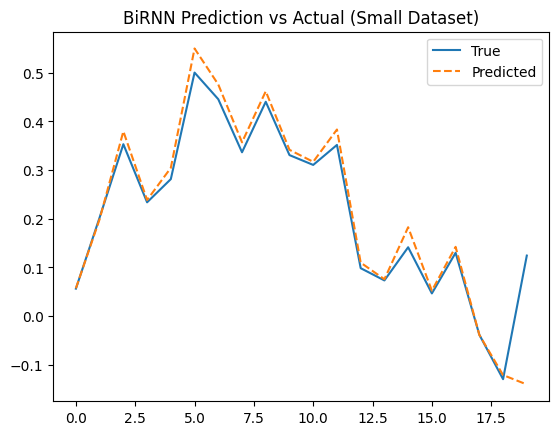

In [22]:
model = models_to_test["BiRNN"]
preds = model.predict(X_small[:1])
plt.plot(y_small[0].flatten(), label="True")
plt.plot(preds.flatten(), label="Predicted", linestyle='--')
plt.title("BiRNN Prediction vs Actual (Small Dataset)")
plt.legend()
plt.show()